# TransTVDiag Evaluation Notebook

Этот ноутбук:
- загружает обученный чекпойнт,
- прогоняет test set,
- считает `confusion matrix` и `classification_report` для `RCL` и `FTI`,
- сохраняет предсказания и таргеты в индексах и в явном виде.

In [12]:
from argparse import Namespace
from pathlib import Path

import dgl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

from core.model.MainModel import MainModel
from prepare_data import prepare_for_graphormer
from process.EventProcess import EventProcess

plt.rcParams['figure.figsize'] = (10, 8)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

In [11]:
!pip install torch==2.1.1
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
!pip install scikit-learn
!pip install fasttext==0.9.2

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
Looking in links: https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
  Using cached https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/packages/packages/fasttext/0.9.2/fasttext-0.9.2.tar.gz (68 kB)
  Preparing metadata (setup.py) ... done
  Using cach

In [5]:
import torch; print('torch=', torch.__version__); print('torch cuda=', torch.version.cuda); print('cuda available=', torch.cuda.is_available())

torch= 2.1.1+cu121
torch cuda= 12.1
cuda available= True


In [16]:
DATASET = 'gaia'
LABELS_FILE = 'gaia.csv'
CHECKPOINT_PATH = Path('logs') / DATASET / 'TransTVDiag.pt'
OUTPUT_DIR = Path('logs') / DATASET / 'evaluation_artifacts'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Если чекпойнт обучался с другими параметрами, поправьте их здесь.
args = Namespace(
    dataset=DATASET,
    labels_file=LABELS_FILE,
    embedding_dim=128,
    graph_hidden=128,
    graph_out=32,
    num_heads=16,
    num_layers=2,
    attn_drop=0.0,
    linear_hidden=[64],
    reconstruct=False,
    aug_percent=0.2,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT_PATH.resolve()}')
print(f'Artifacts dir: {OUTPUT_DIR.resolve()}')

Device: cuda
Checkpoint: /workdir/TransTVDiag/logs/gaia/TransTVDiag.pt
Artifacts dir: /workdir/TransTVDiag/logs/gaia/evaluation_artifacts


In [17]:
labels_df = pd.read_csv(Path('data') / DATASET / LABELS_FILE)
instance_names = sorted(labels_df['instance'].unique().tolist())
failure_type_names = sorted(labels_df['anomaly_type'].unique().tolist())

args.N_I = len(instance_names)
args.N_T = len(failure_type_names)

instance_id_to_name = {idx: name for idx, name in enumerate(instance_names)}
failure_type_id_to_name = {idx: name for idx, name in enumerate(failure_type_names)}

test_meta = labels_df[labels_df['data_type'] == 'test'].reset_index(drop=True).copy()
print('Test samples:', len(test_meta))
print('Instance labels:', instance_id_to_name)
print('Failure type labels:', failure_type_id_to_name)

Test samples: 939
Instance labels: {0: 'dbservice1', 1: 'dbservice2', 2: 'logservice1', 3: 'logservice2', 4: 'mobservice1', 5: 'mobservice2', 6: 'redisservice1', 7: 'redisservice2', 8: 'webservice1', 9: 'webservice2'}
Failure type labels: {0: '[access permission denied exception]', 1: '[file moving program]', 2: '[login failure]', 3: '[memory_anomalies]', 4: '[normal memory freed label]'}


In [18]:
class NotebookLogger:
    def info(self, msg):
        pass
    def debug(self, msg):
        pass

def collate(samples):
    graphs, labels = map(list, zip(*samples))
    labels = torch.tensor(labels)
    return prepare_for_graphormer(graphs, labels)

processor = EventProcess(args, NotebookLogger())
_, test_data = processor.process(reconstruct=False)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False, collate_fn=collate)

len(test_data)

939

In [19]:
model = MainModel(args).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
model.eval()

records = []

for sample_idx, batch in enumerate(test_loader):
    labels, metric_feat, trace_feat, log_feat, in_degree, out_degree, attn_mask, path_data, dist = batch

    target_root_idx = labels[:, 0].item()
    target_type_idx = labels[:, 1].item()

    with torch.no_grad():
        _, root_logits, type_logits = model(
            metric_feat.to(DEVICE),
            trace_feat.to(DEVICE),
            log_feat.to(DEVICE),
            in_degree.to(DEVICE),
            out_degree.to(DEVICE),
            dist.to(DEVICE),
            path_data.to(DEVICE),
            attn_mask.to(DEVICE),
        )

    root_probs = torch.softmax(root_logits, dim=1).cpu()[0]
    type_probs = torch.softmax(type_logits, dim=1).cpu()[0]

    pred_root_idx = int(root_probs.argmax().item())
    pred_type_idx = int(type_probs.argmax().item())

    topk_root = min(5, len(instance_names))
    root_topk_scores, root_topk_indices = torch.topk(root_probs, k=topk_root)
    type_topk_scores, type_topk_indices = torch.topk(type_probs, k=len(failure_type_names))

    meta = test_meta.iloc[sample_idx]
    records.append({
        'sample_position': sample_idx,
        'data_index': int(meta['index']),
        'datetime': meta['datetime'],
        'service': meta['service'],
        'message': meta['message'],
        'target_root_idx': target_root_idx,
        'target_root_name': instance_id_to_name[target_root_idx],
        'pred_root_idx': pred_root_idx,
        'pred_root_name': instance_id_to_name[pred_root_idx],
        'target_type_idx': target_type_idx,
        'target_type_name': failure_type_id_to_name[target_type_idx],
        'pred_type_idx': pred_type_idx,
        'pred_type_name': failure_type_id_to_name[pred_type_idx],
        'root_correct': pred_root_idx == target_root_idx,
        'type_correct': pred_type_idx == target_type_idx,
        'pred_root_confidence': float(root_probs[pred_root_idx].item()),
        'pred_type_confidence': float(type_probs[pred_type_idx].item()),
        'root_top5_indices': [int(x) for x in root_topk_indices.tolist()],
        'root_top5_names': [instance_id_to_name[int(x)] for x in root_topk_indices.tolist()],
        'root_top5_scores': [float(x) for x in root_topk_scores.tolist()],
        'type_ranked_indices': [int(x) for x in type_topk_indices.tolist()],
        'type_ranked_names': [failure_type_id_to_name[int(x)] for x in type_topk_indices.tolist()],
        'type_ranked_scores': [float(x) for x in type_topk_scores.tolist()],
    })

predictions_df = pd.DataFrame(records)
predictions_df.head()

,sample_position,data_index,datetime,service,message,target_root_idx,target_root_name,pred_root_idx,pred_root_name,target_type_idx,target_type_name,pred_type_idx,pred_type_name,root_correct,type_correct,pred_root_confidence,pred_type_confidence,root_top5_indices,root_top5_names,root_top5_scores,type_ranked_indices,type_ranked_names,type_ranked_scores
0,0,160,2021-07-08,webservice,"2021-07-08 12:31:51,764 | WARNING | 0.0.0.3 | 172.17.0.4 | webservice2 | [memory_anomalies] trigger a high memory pr...",9,webservice2,7,redisservice2,3,[memory_anomalies],3,[memory_anomalies],False,True,0.878877,0.999996,"[7, 1, 3, 8, 6]","[redisservice2, dbservice2, logservice2, webservice1, redisservice1]","[0.8788768649101257, 0.06904809176921844, 0.030142767354846, 0.01642627827823162, 0.0027147564105689526]","[3, 4, 1, 0, 2]","[[memory_anomalies], [normal memory freed label], [file moving program], [access permission denied exception], [logi...","[0.9999958276748657, 3.3261615044466453e-06, 6.838362196504022e-07, 6.289094045541788e-08, 1.1680656442081272e-08]"
1,1,161,2021-07-08,redisservice,"2021-07-08 13:57:49,696 | WARNING | 0.0.0.2 | 172.17.0.4 | redisservice2 | [memory_anomalies] trigger a high memory ...",7,redisservice2,5,mobservice2,3,[memory_anomalies],3,[memory_anomalies],False,True,0.923047,0.999977,"[5, 3, 0, 7, 8]","[mobservice2, logservice2, dbservice1, redisservice2, webservice1]","[0.9230469465255737, 0.05025917664170265, 0.022931382060050964, 0.002333597745746374, 0.0013289613416418433]","[3, 4, 2, 1, 0]","[[memory_anomalies], [normal memory freed label], [login failure], [file moving program], [access permission denied ...","[0.9999765157699585, 2.3370090275420807e-05, 5.648506018474109e-08, 3.3001594346160346e-08, 2.2124677201418308e-08]"
2,2,162,2021-07-08,logservice,"2021-07-08 14:58:15,995 | WARNING | 0.0.0.2 | 172.17.0.3 | logservice2 | [memory_anomalies] trigger a high memory pr...",3,logservice2,4,mobservice1,3,[memory_anomalies],3,[memory_anomalies],False,True,0.489526,0.999908,"[4, 3, 8, 2, 7]","[mobservice1, logservice2, webservice1, logservice1, redisservice2]","[0.4895264804363251, 0.2697103023529053, 0.22519899904727936, 0.01077954936772585, 0.002412852831184864]","[3, 4, 0, 2, 1]","[[memory_anomalies], [normal memory freed label], [access permission denied exception], [login failure], [file movin...","[0.9999076128005981, 9.171948477160186e-05, 2.3839086793486786e-07, 2.201506816845722e-07, 1.9808052797998243e-07]"
3,3,163,2021-07-08,mobservice,"2021-07-08 15:31:25,667 | WARNING | 0.0.0.1 | 172.17.0.5 | mobservice1 | 60bf18c60ac0d786 | wait for 11 seconds for ...",4,mobservice1,4,mobservice1,2,[login failure],2,[login failure],True,True,0.964272,0.999633,"[4, 5, 9, 7, 3]","[mobservice1, mobservice2, webservice2, redisservice2, logservice2]","[0.9642724394798279, 0.03268253803253174, 0.0006518401787616313, 0.0005059952381998301, 0.00039608016959391534]","[2, 4, 3, 0, 1]","[[login failure], [normal memory freed label], [memory_anomalies], [access permission denied exception], [file movin...","[0.9996331930160522, 0.0003441737499088049, 1.084371888282476e-05, 6.6237093960808124e-06, 5.126408268552041e-06]"
4,4,164,2021-07-08,mobservice,"2021-07-08 16:07:49,570 | WARNING | 0.0.0.4 | 172.17.0.2 | mobservice2 | f4785a5235665fdb | wait for 11 seconds for ...",5,mobservice2,5,mobservice2,2,[login failure],2,[login failure],True,True,0.999806,0.999913,"[5, 4, 0, 3, 6]","[mobservice2, mobservice1, dbservice1, logservice2, redisservice1]","[0.9998055100440979, 8.779027120908722e-05, 4.4769960368284956e-05, 1.9475273802527227e-05, 1.3963872333988547e-05]","[2, 4, 3, 1, 0]","[[login failure], [normal memory freed label], [memory_anomalies], [file moving program], [access permission denied ...","[0.9999128580093384, 4.6456774725811556e-05, 2.8301181373535655e-05, 6.920650321262656e-06, 5.46718729310669e-06]"


In [20]:
predictions_csv = OUTPUT_DIR / 'test_predictions.csv'
predictions_parquet = OUTPUT_DIR / 'test_predictions.parquet'

predictions_df.to_csv(predictions_csv, index=False)
print(f'Saved: {predictions_csv.resolve()}')

# try:
#     predictions_df.to_parquet(predictions_parquet, index=False)
#     print(f'Saved: {predictions_parquet.resolve()}')
# except Exception as exc:
#     print(f'Parquet export skipped: {exc}')

Saved: /workdir/TransTVDiag/logs/gaia/evaluation_artifacts/test_predictions.csv


In [21]:
root_report = classification_report(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
    output_dict=True,
    zero_division=0,
)
type_report = classification_report(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
    output_dict=True,
    zero_division=0,
)

root_report_df = pd.DataFrame(root_report).transpose()
type_report_df = pd.DataFrame(type_report).transpose()

root_report_df.to_csv(OUTPUT_DIR / 'classification_report_rcl.csv')
type_report_df.to_csv(OUTPUT_DIR / 'classification_report_fti.csv')

display(root_report_df)
display(type_report_df)

,precision,recall,f1-score,support
dbservice1,0.130435,0.187500,0.153846,48.000000
dbservice2,0.104348,0.187500,0.134078,64.000000
logservice1,0.137255,0.311111,0.190476,45.000000
logservice2,0.000000,0.000000,0.000000,35.000000
mobservice1,0.817204,0.558824,0.663755,272.000000
mobservice2,0.639640,0.766187,0.697218,278.000000
redisservice1,0.000000,0.000000,0.000000,30.000000
redisservice2,0.065217,0.069767,0.067416,43.000000
webservice1,0.324324,0.190476,0.240000,63.000000
webservice2,0.250000,0.032787,0.057971,61.000000


,precision,recall,f1-score,support
[access permission denied exception],0.000000,0.000000,0.000000,15.000000
[file moving program],0.846154,0.407407,0.550000,27.000000
[login failure],0.982833,1.000000,0.991342,458.000000
[memory_anomalies],0.924612,0.978873,0.950969,426.000000
[normal memory freed label],0.111111,0.076923,0.090909,13.000000
accuracy,0.944622,0.944622,0.944622,0.944622
macro avg,0.572942,0.492641,0.516644,939.000000
weighted avg,0.924721,0.944622,0.932033,939.000000


In [22]:
print('RCL report')
print(classification_report(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
    zero_division=0,
))

print('FTI report')
print(classification_report(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
    zero_division=0,
))

RCL report
               precision    recall  f1-score   support

   dbservice1       0.13      0.19      0.15        48
   dbservice2       0.10      0.19      0.13        64
  logservice1       0.14      0.31      0.19        45
  logservice2       0.00      0.00      0.00        35
  mobservice1       0.82      0.56      0.66       272
  mobservice2       0.64      0.77      0.70       278
redisservice1       0.00      0.00      0.00        30
redisservice2       0.07      0.07      0.07        43
  webservice1       0.32      0.19      0.24        63
  webservice2       0.25      0.03      0.06        61

     accuracy                           0.44       939
    macro avg       0.25      0.23      0.22       939
 weighted avg       0.49      0.44      0.45       939

FTI report
                                      precision    recall  f1-score   support

[access permission denied exception]       0.00      0.00      0.00        15
               [file moving program]       0.85 

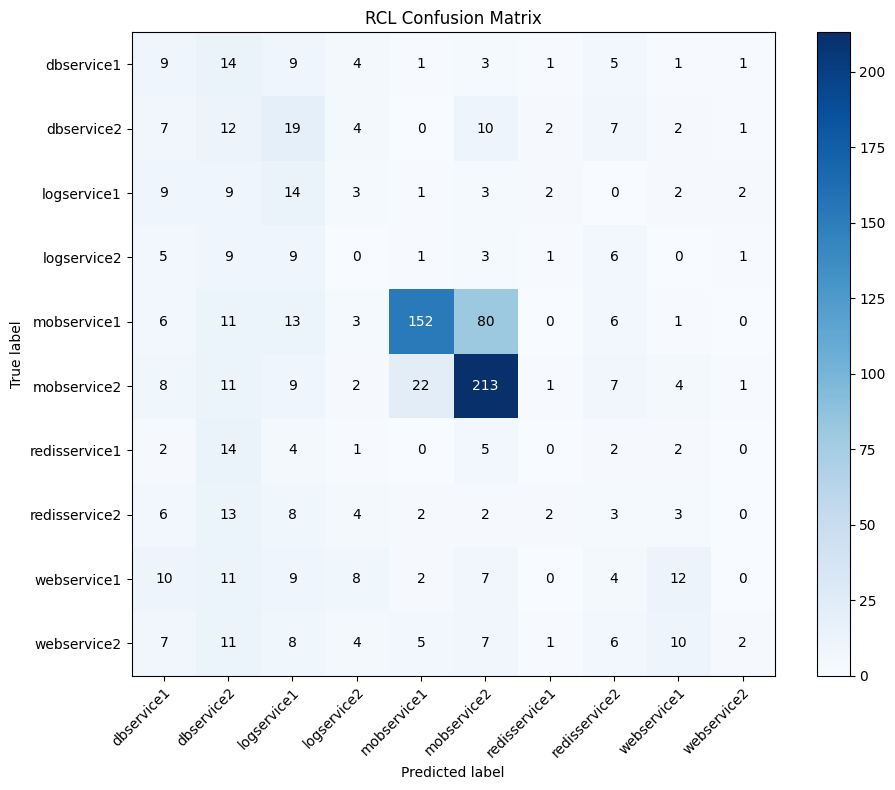

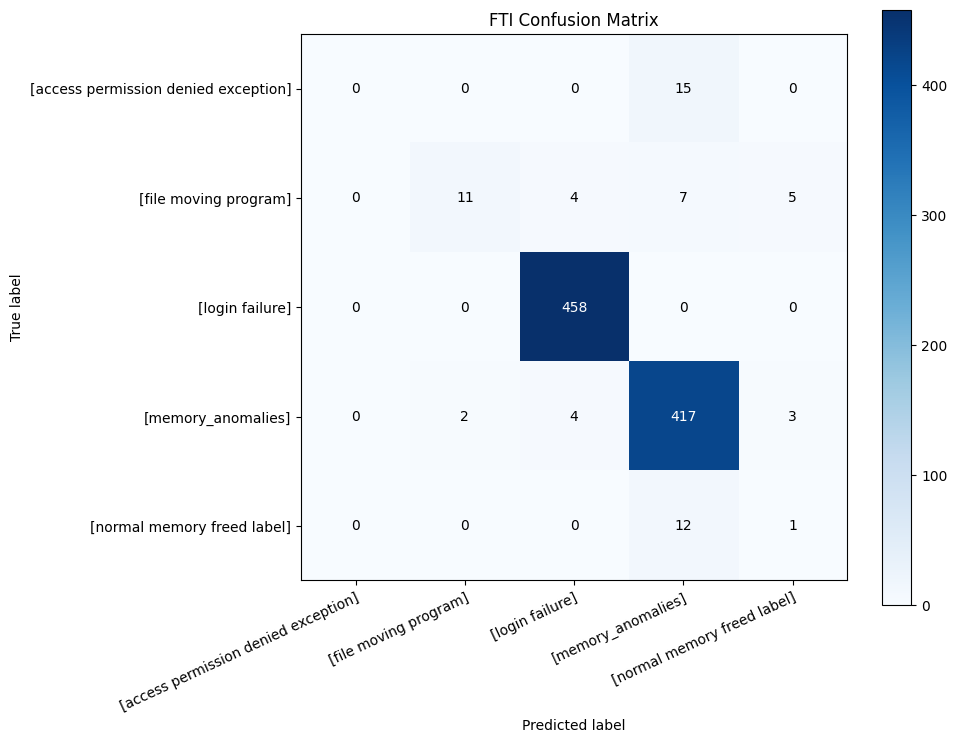

In [23]:
def plot_confusion_matrix(cm, labels, title, rotate_x=45):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        title=title,
        ylabel='True label',
        xlabel='Predicted label',
    )
    plt.setp(ax.get_xticklabels(), rotation=rotate_x, ha='right', rotation_mode='anchor')

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], 'd'),
                ha='center',
                va='center',
                color='white' if cm[i, j] > threshold else 'black',
            )
    fig.tight_layout()
    return fig

root_cm = confusion_matrix(
    predictions_df['target_root_name'],
    predictions_df['pred_root_name'],
    labels=instance_names,
)
type_cm = confusion_matrix(
    predictions_df['target_type_name'],
    predictions_df['pred_type_name'],
    labels=failure_type_names,
)

pd.DataFrame(root_cm, index=instance_names, columns=instance_names).to_csv(OUTPUT_DIR / 'confusion_matrix_rcl.csv')
pd.DataFrame(type_cm, index=failure_type_names, columns=failure_type_names).to_csv(OUTPUT_DIR / 'confusion_matrix_fti.csv')

fig_root = plot_confusion_matrix(root_cm, instance_names, 'RCL Confusion Matrix')
fig_type = plot_confusion_matrix(type_cm, failure_type_names, 'FTI Confusion Matrix', rotate_x=25)

fig_root.savefig(OUTPUT_DIR / 'confusion_matrix_rcl.png', bbox_inches='tight')
fig_type.savefig(OUTPUT_DIR / 'confusion_matrix_fti.png', bbox_inches='tight')
plt.show()

In [24]:
summary = pd.DataFrame([
    {
        'task': 'RCL',
        'accuracy': (predictions_df['target_root_name'] == predictions_df['pred_root_name']).mean(),
        'macro_f1': root_report_df.loc['macro avg', 'f1-score'],
        'weighted_f1': root_report_df.loc['weighted avg', 'f1-score'],
    },
    {
        'task': 'FTI',
        'accuracy': (predictions_df['target_type_name'] == predictions_df['pred_type_name']).mean(),
        'macro_f1': type_report_df.loc['macro avg', 'f1-score'],
        'weighted_f1': type_report_df.loc['weighted avg', 'f1-score'],
    },
])

summary.to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
summary

,task,accuracy,macro_f1,weighted_f1
0,RCL,0.444089,0.220476,0.447774
1,FTI,0.944622,0.516644,0.932033


In [5]:
%pip install torch==2.1.1 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 2.9 MB/s eta 0:00:000:00:010:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 78.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 82.7 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 86.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install torchdata==0.7.1

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 132.2 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
Looking in links: https://data.dgl.ai/wheels/cu118/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 748.2/748.2 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 106.1 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install pandas scikit-learn fasttext==0.9.2 "pydantic<2" tensorboard

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 111.4 MB/s eta 0:00:00a 0:00:01
  Using cached https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/packages/packages/fasttext/0.9.2/fasttext-0.9.2.tar.gz (68 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 58.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 130.6 MB/s eta 0:00:0000:01
  Using cached https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/packages/packages/pybind11/3.0.2/pybind11-3.0.2-py3-none-any.whl (310 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 121.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 75.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 63.8 MB/s eta 0:00:00
  Using cached https://artifactory.tcsbank.ru/artifactory/api/pypi/pyth